In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import torch
from hydra import compose, initialize
from PIL import Image 


project_root = Path().resolve().parent
sys.path.append(str(project_root))

from yolo import (
    AugmentationComposer,
    Config,
    PostProcess,
    create_converter,
    create_model,
    draw_bboxes,
)

In [3]:
CONFIG_PATH = "../yolo/config"
CONFIG_NAME = "config"
MODEL = "v9-c"

DEVICE = 'cpu'
CLASS_NUM = 80
IMAGE_PATH = '../demo/images/inference/image.png'

device = torch.device(DEVICE)

In [4]:
with initialize(config_path=CONFIG_PATH, version_base=None, job_name="notebook_job"):
    cfg: Config = compose(config_name=CONFIG_NAME, overrides=["task=inference", f"task.data.source={IMAGE_PATH}", f"model={MODEL}"])
    model = create_model(cfg.model, class_num=CLASS_NUM).to(device)

    transform = AugmentationComposer([], cfg.image_size)

    converter = create_converter(cfg.model.name, model, cfg.model.anchor, cfg.image_size, device)
    post_proccess = PostProcess(converter, cfg.task.nms)

[06/10/25 21:44:21] INFO     🚜 Building YOLO                                                            ]8;id=778314;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=831741;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#35\35]8;;\

                    INFO       🏗  Building backbone                                                      ]8;id=338525;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=649995;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#38\38]8;;\

                    INFO       🏗  Building neck                                                          ]8;id=598793;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=346950;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#38\38]8;;\

                    INFO       🏗  Building head                                                          ]8;id=623580;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=554909;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#38\38]8;;\

                    INFO       🏗  Building detection                                                     ]8;id=508793;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=21204;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#38\38]8;;\

                    INFO       🏗  Building auxiliary                                                     ]8;id=317711;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=912499;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#38\38]8;;\

[06/10/25 21:44:22] INFO     ✅ Success load model & weight                                             ]8;id=141101;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=645349;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#183\183]8;;\

                    INFO     🈶 Found stride of model [8, 16, 32]                         ]8;id=483701;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\utils\bounding_box_utils.py\bounding_box_utils.py]8;;\:]8;id=657843;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\utils\bounding_box_utils.py#343\343]8;;\

In [5]:
pil_image = Image.open(IMAGE_PATH)
image, bbox, rev_tensor = transform(pil_image)
image = image.to(device)[None]
rev_tensor = rev_tensor.to(device)[None]

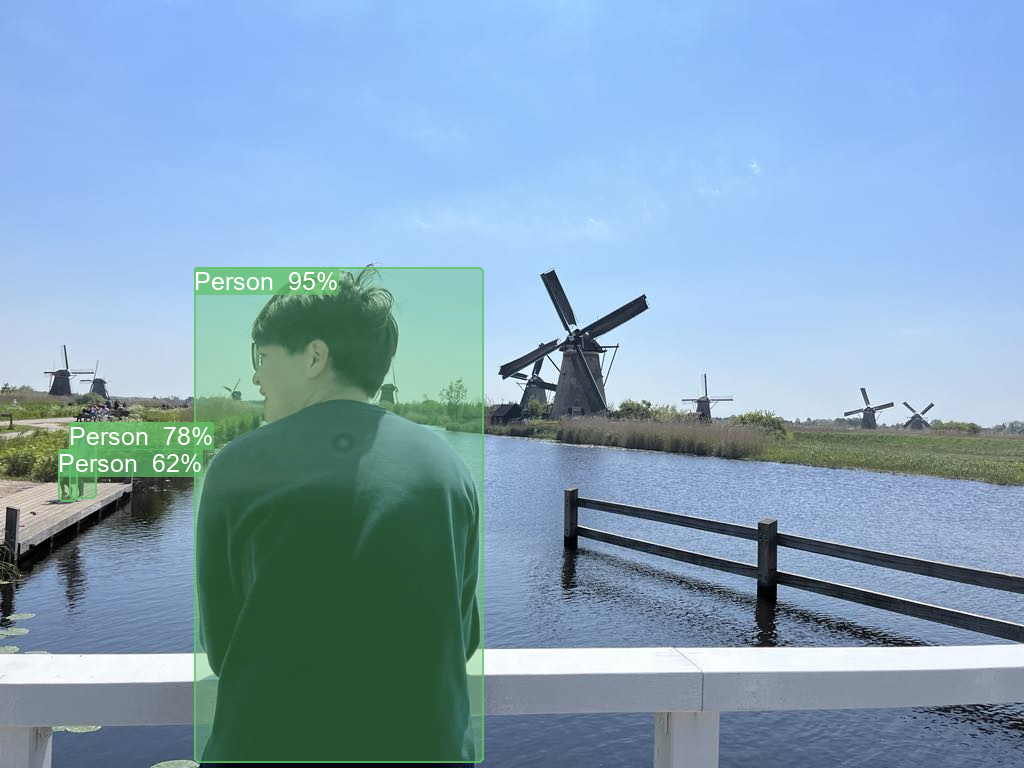

In [6]:
with torch.no_grad():
    predict = model(image)
    pred_bbox = post_proccess(predict, rev_tensor)

draw_bboxes(pil_image, pred_bbox, idx2label=cfg.dataset.class_list)